# Customer Churn Analysis — Predictive Modeling (ANN)
### Stage 3.1: Define, Train, and Evaluate an Artificial Neural Network

**Objective:** Build on the cleaned dataset from `01_data_prep_clustering.ipynb` to train a neural
network that predicts whether a customer will churn, and evaluate how well it performs.

This notebook is self-contained: it repeats the data preparation steps (load → encode → split →
scale) so it can be run independently, using the same methodology as the clustering notebook.


## 1. Import Libraries

In [1]:
import warnings
warnings.filterwarnings("ignore")

import os
os.environ["TF_CPP_MIN_LOG_LEVEL"] = "3"   # suppress TensorFlow INFO/WARNING C++ log noise
os.environ["TF_ENABLE_ONEDNN_OPTS"] = "0"  # silence the oneDNN startup notice (this project's model is tiny; no meaningful speed cost)

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.preprocessing import LabelEncoder, StandardScaler
from sklearn.model_selection import train_test_split
from sklearn.metrics import (
    accuracy_score, precision_score, recall_score, f1_score,
    confusion_matrix, classification_report, roc_curve, roc_auc_score
)

import tensorflow as tf
from tensorflow import keras
from tensorflow.keras import layers

tf.random.set_seed(42)
np.random.seed(42)

sns.set_style("whitegrid")
plt.rcParams["figure.figsize"] = (8, 5)
pd.set_option("display.max_columns", None)

print("TensorFlow version:", tf.__version__)


TensorFlow version: 2.21.0


## 2. Data Preparation (recap)

Same steps as the clustering notebook: load data, encode categorical variables, split into
train/test, then scale. The one key difference from the clustering stage: **the scaler is fit only
on the training set**, and reused (not refit) on the test set — this prevents information from the
test set leaking into training, which matters for a supervised model we'll evaluate for generalisation.


In [2]:
df = pd.read_csv("Dataset_ATS_v2.csv")
print("Shape:", df.shape)
df.head()


Shape: (7043, 10)


,gender,SeniorCitizen,Dependents,tenure,PhoneService,MultipleLines,InternetService,Contract,MonthlyCharges,Churn
0,Female,0,No,1,No,No,DSL,Month-to-month,25,Yes
1,Male,0,No,41,Yes,No,DSL,One year,25,No
2,Female,0,Yes,52,Yes,No,DSL,Month-to-month,19,No
3,Female,0,No,1,Yes,No,DSL,One year,76,Yes
4,Male,0,No,67,Yes,No,Fiber optic,Month-to-month,51,No


In [3]:
df_proc = df.copy()

binary_cols = ["gender", "Dependents", "PhoneService", "MultipleLines", "InternetService"]
le_dict = {}
for c in binary_cols:
    le = LabelEncoder()
    df_proc[c] = le.fit_transform(df_proc[c])
    le_dict[c] = dict(zip(le.classes_, le.transform(le.classes_)))

df_proc = pd.get_dummies(df_proc, columns=["Contract"], prefix="Contract")

churn_le = LabelEncoder()
df_proc["Churn_encoded"] = churn_le.fit_transform(df_proc["Churn"])

feature_cols = [c for c in df_proc.columns if c not in ["Churn", "Churn_encoded"]]
print("Features:", feature_cols)
df_proc.head()


Features: ['gender', 'SeniorCitizen', 'Dependents', 'tenure', 'PhoneService', 'MultipleLines', 'InternetService', 'MonthlyCharges', 'Contract_Month-to-month', 'Contract_One year', 'Contract_Two year']


,gender,SeniorCitizen,Dependents,tenure,PhoneService,MultipleLines,InternetService,MonthlyCharges,Churn,Contract_Month-to-month,Contract_One year,Contract_Two year,Churn_encoded
0,0,0,0,1,0,0,0,25,Yes,True,False,False,1
1,1,0,0,41,1,0,0,25,No,False,True,False,0
2,0,0,1,52,1,0,0,19,No,True,False,False,0
3,0,0,0,1,1,0,0,76,Yes,False,True,False,1
4,1,0,0,67,1,0,1,51,No,True,False,False,0


In [4]:
X = df_proc[feature_cols].astype(float)
y = df_proc["Churn_encoded"]

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

# Fit the scaler on TRAINING data only, then apply to both sets
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

print("Train:", X_train_scaled.shape, " Test:", X_test_scaled.shape)
print(f"Churn rate - train: {y_train.mean()*100:.1f}%  |  test: {y_test.mean()*100:.1f}%")


Train: (5634, 11)  Test: (1409, 11)
Churn rate - train: 26.5%  |  test: 26.5%


## 3. Predictive Modeling — Artificial Neural Network

### 3.1 Define the Model Architecture

A small feed-forward network is appropriate here: the input is only 11 features, so a large/deep
network would overfit. Architecture:

- **Input layer**: 11 features
- **Hidden layer 1**: 16 units, ReLU activation
- **Dropout**: 0.3 (regularisation to reduce overfitting)
- **Hidden layer 2**: 8 units, ReLU activation
- **Output layer**: 1 unit, Sigmoid activation (binary churn probability)

Loss: binary cross-entropy (standard for binary classification). Optimiser: Adam.


In [5]:
n_features = X_train_scaled.shape[1]

model = keras.Sequential([
    layers.Input(shape=(n_features,)),
    layers.Dense(16, activation="relu"),
    layers.Dropout(0.3),
    layers.Dense(8, activation="relu"),
    layers.Dense(1, activation="sigmoid"),
])

model.compile(
    optimizer=keras.optimizers.Adam(learning_rate=0.001),
    loss="binary_crossentropy",
    metrics=["accuracy", keras.metrics.AUC(name="auc")],
)

model.summary()


Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ dense (Dense)                   │ (None, 16)             │           192 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 16)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 8)              │           136 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 1)              │             9 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 337 (1.32 KB)

 Trainable params: 337 (1.32 KB)

 Non-trainable params: 0 (0.00 B)

### 3.2 Handle Class Imbalance

The dataset has a ~26.5% churn rate (imbalanced). Without adjustment, the model can reach high
accuracy just by predicting "No churn" for everyone. We apply **class weights** so the minority
class (churners) contributes proportionally more to the loss during training.

In [6]:
from sklearn.utils.class_weight import compute_class_weight

class_weights = compute_class_weight(
    class_weight="balanced", classes=np.unique(y_train), y=y_train
)
class_weight_dict = dict(enumerate(class_weights))
print("Class weights:", class_weight_dict)


Class weights: {0: np.float64(0.6805991785455424), 1: np.float64(1.8842809364548494)}


### 3.3 Train the Model

In [7]:
early_stop = keras.callbacks.EarlyStopping(
    monitor="val_loss", patience=15, restore_best_weights=True
)

history = model.fit(
    X_train_scaled, y_train,
    validation_split=0.2,
    epochs=150,
    batch_size=32,
    class_weight=class_weight_dict,
    callbacks=[early_stop],
    verbose=0,
)

print(f"Training stopped at epoch {len(history.history['loss'])} (early stopping).")


Training stopped at epoch 72 (early stopping).


### 3.4 Training Curves — Check for Convergence / Overfitting

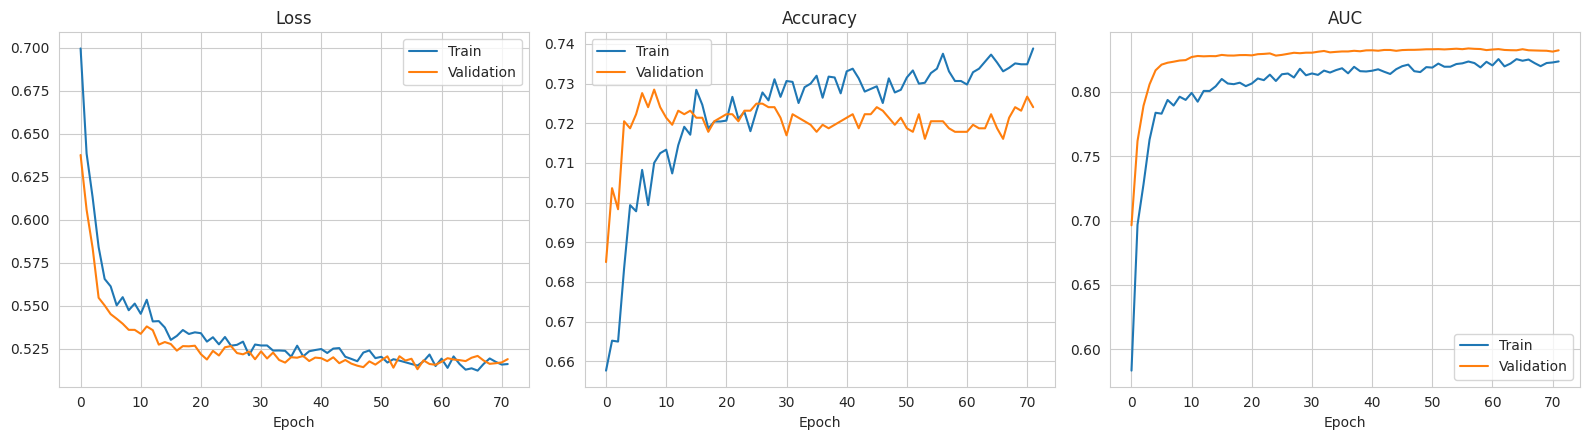

In [8]:
fig, axes = plt.subplots(1, 3, figsize=(16, 4.5))

axes[0].plot(history.history["loss"], label="Train")
axes[0].plot(history.history["val_loss"], label="Validation")
axes[0].set_title("Loss")
axes[0].set_xlabel("Epoch")
axes[0].legend()

axes[1].plot(history.history["accuracy"], label="Train")
axes[1].plot(history.history["val_accuracy"], label="Validation")
axes[1].set_title("Accuracy")
axes[1].set_xlabel("Epoch")
axes[1].legend()

axes[2].plot(history.history["auc"], label="Train")
axes[2].plot(history.history["val_auc"], label="Validation")
axes[2].set_title("AUC")
axes[2].set_xlabel("Epoch")
axes[2].legend()

plt.tight_layout()
plt.show()


## 4. Predict Customer Churn & Evaluate Performance

### 4.1 Predictions on the Test Set

In [9]:
y_pred_proba = model.predict(X_test_scaled, verbose=0).flatten()
y_pred = (y_pred_proba >= 0.5).astype(int)

acc = accuracy_score(y_test, y_pred)
prec = precision_score(y_test, y_pred)
rec = recall_score(y_test, y_pred)
f1 = f1_score(y_test, y_pred)
auc = roc_auc_score(y_test, y_pred_proba)

print(f"Accuracy:  {acc:.3f}")
print(f"Precision: {prec:.3f}  (of predicted churners, how many actually churned)")
print(f"Recall:    {rec:.3f}  (of actual churners, how many we caught)")
print(f"F1 Score:  {f1:.3f}")
print(f"ROC-AUC:   {auc:.3f}")


Accuracy:  0.724
Precision: 0.487  (of predicted churners, how many actually churned)
Recall:    0.767  (of actual churners, how many we caught)
F1 Score:  0.596
ROC-AUC:   0.810


**Why look beyond accuracy:** with ~26.5% churn, a model predicting "No" for every customer would
score ~73.5% accuracy while catching zero real churners. **Recall** matters most for this business
problem — missing an at-risk customer (false negative) costs a potential lost customer, while a false
positive just means an unnecessary retention offer.

In [10]:
print(classification_report(y_test, y_pred, target_names=["No Churn", "Churn"]))


              precision    recall  f1-score   support

    No Churn       0.89      0.71      0.79      1035
       Churn       0.49      0.77      0.60       374

    accuracy                           0.72      1409
   macro avg       0.69      0.74      0.69      1409
weighted avg       0.79      0.72      0.74      1409



### 4.2 Confusion Matrix

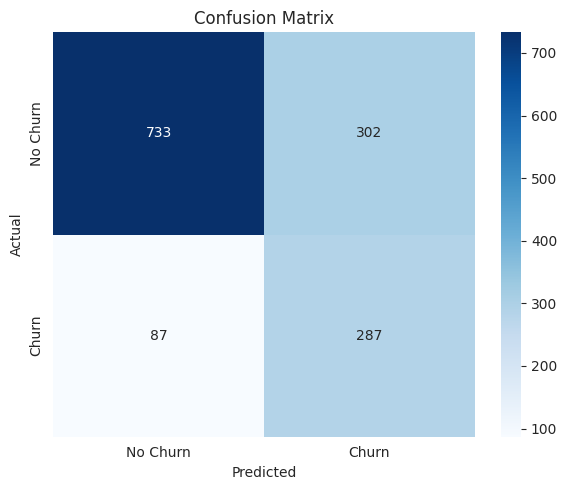

In [11]:
cm = confusion_matrix(y_test, y_pred)
plt.figure(figsize=(6, 5))
sns.heatmap(cm, annot=True, fmt="d", cmap="Blues",
            xticklabels=["No Churn", "Churn"], yticklabels=["No Churn", "Churn"])
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.title("Confusion Matrix")
plt.tight_layout()
plt.show()


### 4.3 ROC Curve

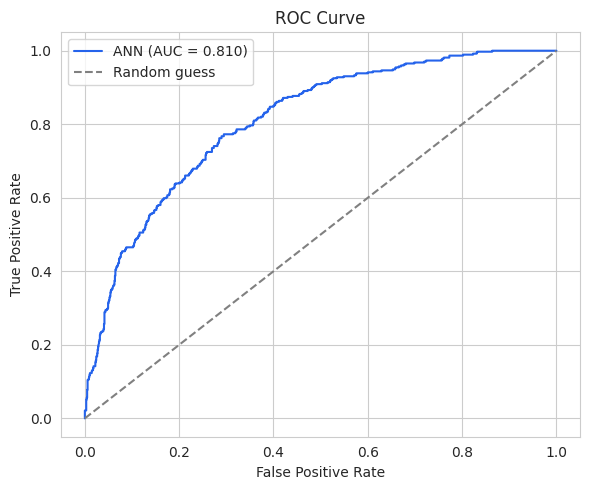

In [12]:
fpr, tpr, _ = roc_curve(y_test, y_pred_proba)
plt.figure(figsize=(6, 5))
plt.plot(fpr, tpr, label=f"ANN (AUC = {auc:.3f})", color="#2563eb")
plt.plot([0, 1], [0, 1], linestyle="--", color="grey", label="Random guess")
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("ROC Curve")
plt.legend()
plt.tight_layout()
plt.show()


### 4.4 Which Attributes Drive Predictions?

Neural networks don't expose feature importance directly like tree models do. We estimate it with
**permutation importance**: shuffle one feature at a time in the test set and measure how much the
model's AUC drops. A larger drop means the model relies on that feature more heavily.

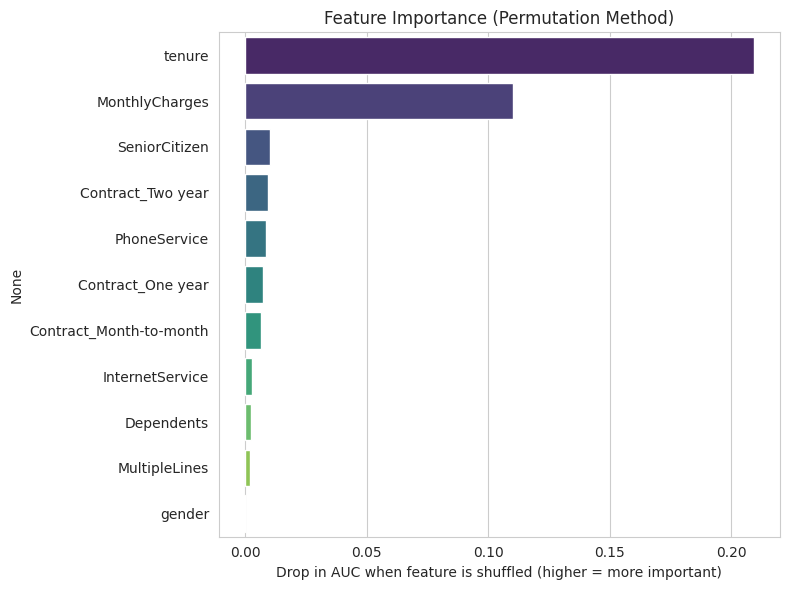

tenure                     0.2096
MonthlyCharges             0.1101
SeniorCitizen              0.0103
Contract_Two year          0.0095
PhoneService               0.0084
Contract_One year          0.0072
Contract_Month-to-month    0.0066
InternetService            0.0027
Dependents                 0.0026
MultipleLines              0.0022
gender                    -0.0003
dtype: float64

In [13]:
def permutation_importance_ann(model, X, y, feature_names, n_repeats=5):
    baseline_auc = roc_auc_score(y, model.predict(X, verbose=0).flatten())
    importances = []
    rng = np.random.RandomState(42)
    for i, feat in enumerate(feature_names):
        drops = []
        for _ in range(n_repeats):
            X_permuted = X.copy()
            rng.shuffle(X_permuted[:, i])
            permuted_auc = roc_auc_score(y, model.predict(X_permuted, verbose=0).flatten())
            drops.append(baseline_auc - permuted_auc)
        importances.append(np.mean(drops))
    return pd.Series(importances, index=feature_names).sort_values(ascending=False)

importances = permutation_importance_ann(model, X_test_scaled, y_test.values, feature_cols)

plt.figure(figsize=(8, 6))
sns.barplot(x=importances.values, y=importances.index, hue=importances.index,
            palette="viridis", legend=False)
plt.xlabel("Drop in AUC when feature is shuffled (higher = more important)")
plt.title("Feature Importance (Permutation Method)")
plt.tight_layout()
plt.show()

importances.round(4)


## 5. Summary (Predictive Modeling)

*(Exact numbers depend on the run above — re-run the notebook to refresh them into this narrative
when writing the Final Report.)*

- The ANN was trained with class weighting to counter the ~26.5% churn imbalance, and early stopping
  to avoid overfitting (training halts once validation loss stops improving).
- **Recall** is the priority metric for this business problem — catching at-risk customers matters
  more than avoiding false alarms, since a missed churner is a lost customer while a false positive
  just costs an unnecessary retention offer.
- Permutation importance shows which attributes the model leans on most — cross-reference this with
  the clustering notebook's finding that **contract type** was the main driver of segment differences,
  to see if the ANN independently confirms contract type (and any other features) as key churn drivers.

## Next Steps

This notebook covers **Stage 3.1 — Predictive Modeling**. Outputs available for the **Final Report**
(Stage 3.2):
- Evaluation metrics (accuracy, precision, recall, F1, AUC) computed above
- Confusion matrix and ROC curve
- Permutation feature importance ranking
- `model` (trained Keras model), `scaler` (fit on training data), `history` (training curves)

Combine these findings with the clustering notebook's segment/churn-rate results to write the final
report: key churn drivers, priority segments, and retention recommendations.
